In [439]:
import numpy as np
import matplotlib.pyplot as plt

### 1.1

In [440]:
A = np.array([[8, 9, 3, 2],
              [9, 8, 4, 3],
              [2, 3, 9, 8],
              [3, 2, 8, 9],
              [5, 5, 5, 5]])

U, S, Vt = np.linalg.svd(A, full_matrices= False)
print("singular_values = ", S)

singular_values =  [24.64768344 11.55038654  1.61729957  0.68162608]


### 1.2

In [441]:
def reconstruct_matrix(U, S, Vt, k):
    Sigma = np.diag(S[:k])
    U = U[:, :k]
    Vt = Vt[:k, :]
    return U @ Sigma @ Vt

In [442]:
print(A, "\n")
A_k = reconstruct_matrix(U, S, Vt, 2)
print(A_k)

[[8 9 3 2]
 [9 8 4 3]
 [2 3 9 8]
 [3 2 8 9]
 [5 5 5 5]] 

[[8.48720343 8.51983466 2.96627073 2.02761123]
 [8.49020835 8.51307961 3.94713468 3.05531871]
 [2.56794548 2.50254661 8.44519165 8.52458949]
 [2.50323995 2.43713475 8.4684576  8.55722072]
 [4.99565608 4.98044064 5.19760379 4.81128725]]


=> Điểm số của các học sinh xấp xỉ điểm số ban đầu

## 1.3

In [443]:
E = A - A_k

Frobenius = 0
for i in range(E.shape[0]):
    for j in range(E.shape[1]):
        Frobenius += E[i][j] ** 2
Frobenius = np.sqrt(Frobenius)
Frobenius

np.float64(1.7550703717163936)

### 2:
## 2.1

In [444]:
np.random.seed(1)
X = np.random.uniform(1, 10, 100)
noise = np.random.normal(0, np.sqrt(5), 100)
y = 15 * X + 8 + noise

### 2.2

In [445]:
def get_gradients(x_i, y_i, w, b):
    return -2 * x_i * (y_i - (w * x_i + b)), -2 * (y_i - (w * x_i + b))

### 2.3

In [446]:
w = 0
b = 0
learning_rate = 0.01
epochs = 10

In [ ]:
Loss = []
for epoch in range(epochs):
    indices = np.random.permutation(100)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for i in range(100):
        x_i = X_shuffled[i]
        y_i = y_shuffled[i]
        
        dw, db = get_gradients(x_i, y_i, w, b)
        w -= learning_rate * dw
        b -= learning_rate * db 
        # print(w, b)
    Loss.append(np.mean((y_shuffled - (w * X_shuffled + b))**2))
    print(np.mean((y_shuffled - (w * X_shuffled + b))**2))

6.276400032565716
5.496273722111409
4.548544718914592
7.912659031020569
5.5777331227876035
4.188841878663907
4.382423116887357
5.626051917391193
6.894326773401406
21.29695596013647


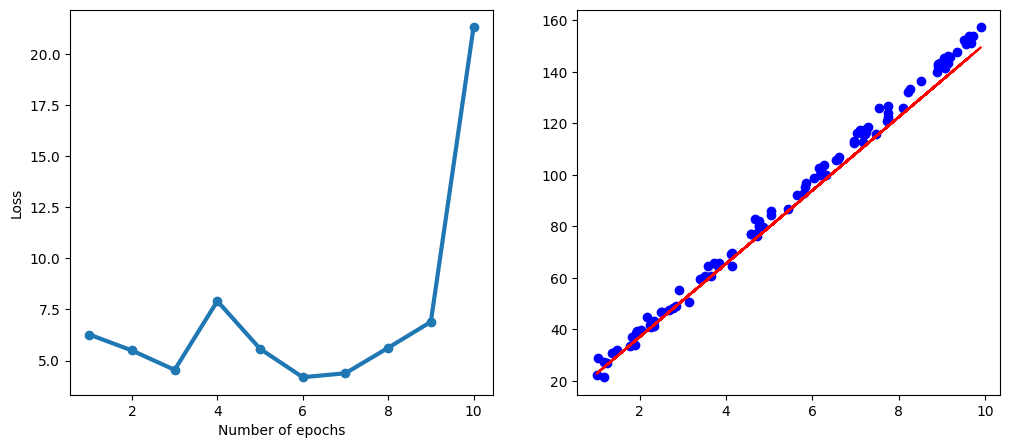

In [448]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, 11), Loss, linewidth=3, marker='o')
plt.xlabel('Number of epochs')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.scatter(X, y, color='blue', label = 'Points')
plt.plot(X, w * X + b, color = 'red', label = ' Regession line')
plt.show()